# 🔧 Home Credit Default Risk — Feature Engineering

This notebook transforms the 8 raw tables into a single, model-ready feature matrix.

## Pipeline
1. Load all tables
2. Engineer features from `application_train/test`
3. Aggregate each secondary table → one row per `SK_ID_CURR`
4. Merge everything into one master table
5. Handle missing values
6. Encode categoricals
7. Save `train_features.csv` and `test_features.csv`

## 0. Setup

In [8]:
import matplotlib
matplotlib.use('Agg')

In [9]:
%matplotlib inline

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_palette('Set2')

DATA_PATH = os.path.expanduser('~/.cache/kagglehub/competitions/home-credit-default-risk')
OUTPUT_PATH = os.path.dirname(DATA_PATH)  # save processed files alongside raw data

print('Data path:', DATA_PATH)
print('Files:', sorted(os.listdir(DATA_PATH)))

Data path: /Users/salmaahmed/.cache/kagglehub/competitions/home-credit-default-risk
Files: ['HomeCredit_columns_description.csv', 'POS_CASH_balance.csv', 'application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'previous_application.csv', 'sample_submission.csv']


---
## 1. Load All Tables

In [10]:
print('Loading tables...')

train        = pd.read_csv(os.path.join(DATA_PATH, 'application_train.csv'))
test         = pd.read_csv(os.path.join(DATA_PATH, 'application_test.csv'))
bureau       = pd.read_csv(os.path.join(DATA_PATH, 'bureau.csv'))
bureau_bal   = pd.read_csv(os.path.join(DATA_PATH, 'bureau_balance.csv'))
prev_app     = pd.read_csv(os.path.join(DATA_PATH, 'previous_application.csv'))
pos_cash     = pd.read_csv(os.path.join(DATA_PATH, 'POS_CASH_balance.csv'))
cc_bal       = pd.read_csv(os.path.join(DATA_PATH, 'credit_card_balance.csv'))
inst         = pd.read_csv(os.path.join(DATA_PATH, 'installments_payments.csv'))

print(f'Train          : {train.shape}')
print(f'Test           : {test.shape}')
print(f'Bureau         : {bureau.shape}')
print(f'Bureau Balance : {bureau_bal.shape}')
print(f'Prev App       : {prev_app.shape}')
print(f'POS CASH       : {pos_cash.shape}')
print(f'CC Balance     : {cc_bal.shape}')
print(f'Installments   : {inst.shape}')

Loading tables...
Train          : (307511, 122)
Test           : (48744, 121)
Bureau         : (1716428, 17)
Bureau Balance : (27299925, 3)
Prev App       : (1670214, 37)
POS CASH       : (10001358, 8)
CC Balance     : (3840312, 23)
Installments   : (13605401, 8)


---
## 2. Application Table Feature Engineering

In [11]:
def engineer_application_features(df):
    """
    Engineer features from the main application table.
    Works on both train and test.
    """
    df = df.copy()

    # ── Age & Employment ─────────────────────────────────────────────────────
    df['AGE_YEARS']       = (-df['DAYS_BIRTH'] / 365).astype(int)
    df['EMPLOYED_YEARS']  = (-df['DAYS_EMPLOYED'] / 365)

    # DAYS_EMPLOYED = 365243 is a known anomaly meaning 'not employed'
    df['EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df.loc[df['DAYS_EMPLOYED'] == 365243, 'EMPLOYED_YEARS'] = np.nan
    df.loc[df['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED']  = np.nan

    df['REGISTRATION_YEARS'] = (-df['DAYS_REGISTRATION'] / 365)
    df['ID_PUBLISH_YEARS']   = (-df['DAYS_ID_PUBLISH'] / 365)

    # ── Income & Credit Ratios ────────────────────────────────────────────────
    df['CREDIT_INCOME_RATIO']   = df['AMT_CREDIT']  / df['AMT_INCOME_TOTAL'].replace(0, np.nan)
    df['ANNUITY_INCOME_RATIO']  = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'].replace(0, np.nan)
    df['CREDIT_TERM']           = df['AMT_ANNUITY'] / df['AMT_CREDIT'].replace(0, np.nan)
    df['GOODS_CREDIT_RATIO']    = df['AMT_GOODS_PRICE'] / df['AMT_CREDIT'].replace(0, np.nan)
    df['INCOME_PER_PERSON']     = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0, np.nan)

    # ── External Source Combinations ─────────────────────────────────────────
    df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    df['EXT_SOURCE_STD']  = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)
    df['EXT_SOURCE_MIN']  = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
    df['EXT_SOURCE_MAX']  = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].max(axis=1)
    df['EXT_SOURCE_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

    # ── Document Flags ────────────────────────────────────────────────────────
    doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT_')]
    df['TOTAL_DOCS_SUBMITTED'] = df[doc_cols].sum(axis=1)

    # ── Social Circle ─────────────────────────────────────────────────────────
    df['SOCIAL_CIRCLE_DEFAULT_RATE'] = (
        df['DEF_30_CNT_SOCIAL_CIRCLE'] / df['OBS_30_CNT_SOCIAL_CIRCLE'].replace(0, np.nan)
    )

    # ── Enquiry Flags ─────────────────────────────────────────────────────────
    enquiry_cols = [c for c in df.columns if c.startswith('AMT_REQ_CREDIT_BUREAU_')]
    df['TOTAL_CREDIT_ENQUIRIES'] = df[enquiry_cols].sum(axis=1)

    # ── Phone / Contact Flags ─────────────────────────────────────────────────
    contact_cols = [c for c in df.columns if c.startswith('FLAG_') and 'CONTACT' in c]
    if contact_cols:
        df['TOTAL_CONTACT_FLAGS'] = df[contact_cols].sum(axis=1)

    return df


train = engineer_application_features(train)
test  = engineer_application_features(test)

print(f'Train after app feature engineering: {train.shape}')
print(f'Test  after app feature engineering: {test.shape}')

# Quick sanity check on new features
new_feats = ['AGE_YEARS','EMPLOYED_YEARS','CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO',
             'EXT_SOURCE_MEAN','EXT_SOURCE_STD','TOTAL_DOCS_SUBMITTED']
print('\nNew features preview:')
display(train[new_feats].describe())

Train after app feature engineering: (307511, 140)
Test  after app feature engineering: (48744, 139)

New features preview:


,AGE_YEARS,EMPLOYED_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EXT_SOURCE_MEAN,EXT_SOURCE_STD,TOTAL_DOCS_SUBMITTED
count,307511.0000,252137.0000,307511.0000,307499.0000,307339.0000,270602.0000,307511.0000
mean,43.4360,6.5320,3.9576,0.1809,0.5093,0.1512,0.9302
std,11.9546,6.4065,2.6897,0.0946,0.1498,0.0999,0.3443
min,20.0000,0.0000,0.0048,0.0002,0.0000,0.0000,0.0000
25%,34.0000,2.1014,2.0187,0.1148,0.4136,0.0724,1.0000
50%,43.0000,4.5151,3.2651,0.1628,0.5245,0.1360,1.0000
75%,53.0000,8.6986,5.1599,0.2291,0.6228,0.2144,1.0000
max,69.0000,49.0740,84.7368,1.8760,0.8789,0.6519,4.0000


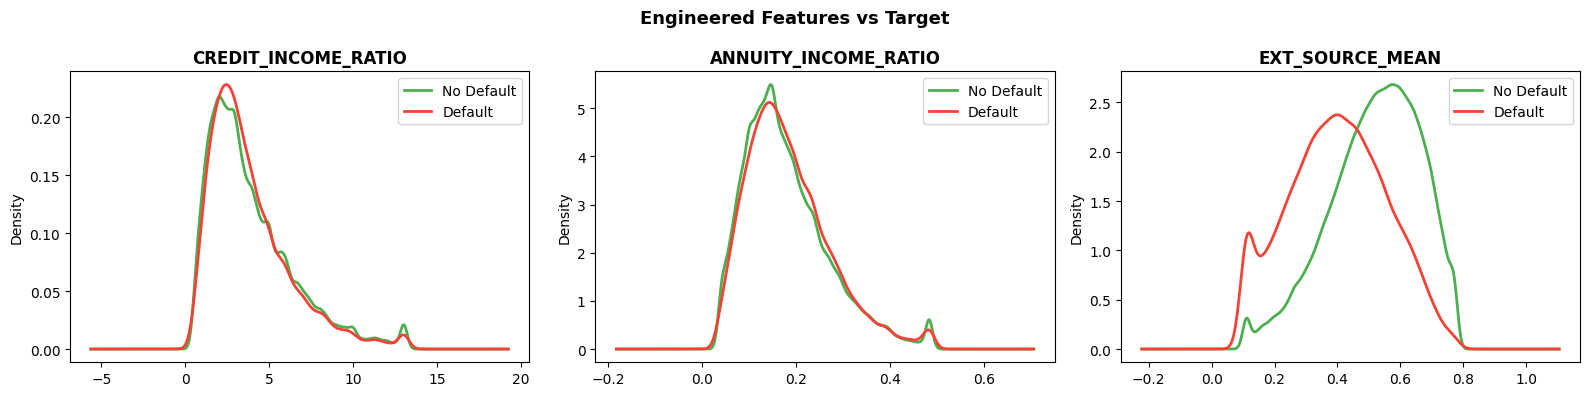

In [12]:
%matplotlib inline
# Visualise key engineered ratios vs TARGET
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'EXT_SOURCE_MEAN']):
    train.loc[train['TARGET']==0, col].clip(
        train[col].quantile(0.01), train[col].quantile(0.99)
    ).plot(kind='kde', ax=ax, label='No Default', color='#4CAF50', linewidth=2)
    train.loc[train['TARGET']==1, col].clip(
        train[col].quantile(0.01), train[col].quantile(0.99)
    ).plot(kind='kde', ax=ax, label='Default', color='#F44336', linewidth=2)
    ax.set_title(col, fontweight='bold')
    ax.legend()

plt.suptitle('Engineered Features vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Bureau Aggregations

In [13]:
def aggregate_bureau(bureau, bureau_bal):
    """
    Aggregate bureau + bureau_balance into one row per SK_ID_CURR.
    """
    # ── Bureau Balance: aggregate by SK_ID_BUREAU first ──────────────────────
    bureau_bal['STATUS_NUM'] = bureau_bal['STATUS'].map(
        {'C': 0, 'X': 0, '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}
    )
    bb_agg = bureau_bal.groupby('SK_ID_BUREAU').agg(
        bb_months_count   = ('MONTHS_BALANCE', 'count'),
        bb_status_mean    = ('STATUS_NUM', 'mean'),
        bb_status_max     = ('STATUS_NUM', 'max'),
        bb_dpd_months     = ('STATUS_NUM', lambda x: (x > 0).sum())
    ).reset_index()

    # Join bureau balance back to bureau
    bureau_full = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')

    # ── Numeric aggregations ──────────────────────────────────────────────────
    num_agg = bureau_full.groupby('SK_ID_CURR').agg(
        bur_count               = ('SK_ID_BUREAU', 'count'),
        bur_active_count        = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
        bur_closed_count        = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
        bur_days_credit_mean    = ('DAYS_CREDIT', 'mean'),
        bur_days_credit_max     = ('DAYS_CREDIT', 'max'),
        bur_days_credit_enddate = ('DAYS_CREDIT_ENDDATE', 'mean'),
        bur_credit_sum_mean     = ('AMT_CREDIT_SUM', 'mean'),
        bur_credit_sum_total    = ('AMT_CREDIT_SUM', 'sum'),
        bur_credit_sum_debt     = ('AMT_CREDIT_SUM_DEBT', 'sum'),
        bur_credit_sum_overdue  = ('AMT_CREDIT_SUM_OVERDUE', 'sum'),
        bur_credit_sum_limit    = ('AMT_CREDIT_SUM_LIMIT', 'sum'),
        bur_prolong_max         = ('CNT_CREDIT_PROLONG', 'max'),
        bur_prolong_sum         = ('CNT_CREDIT_PROLONG', 'sum'),
        bur_overdue_count       = ('AMT_CREDIT_SUM_OVERDUE', lambda x: (x > 0).sum()),
        # bureau balance rollup
        bur_bb_status_mean      = ('bb_status_mean', 'mean'),
        bur_bb_status_max       = ('bb_status_max', 'max'),
        bur_bb_dpd_months_sum   = ('bb_dpd_months', 'sum'),
    ).reset_index()

    # ── Derived ratios ────────────────────────────────────────────────────────
    num_agg['bur_active_ratio']   = num_agg['bur_active_count'] / num_agg['bur_count'].replace(0, np.nan)
    num_agg['bur_overdue_ratio']  = num_agg['bur_overdue_count'] / num_agg['bur_count'].replace(0, np.nan)
    num_agg['bur_debt_credit_ratio'] = (
        num_agg['bur_credit_sum_debt'] / num_agg['bur_credit_sum_total'].replace(0, np.nan)
    )

    print(f'Bureau aggregated: {num_agg.shape}')
    return num_agg


bureau_agg = aggregate_bureau(bureau, bureau_bal)
display(bureau_agg.head(3))

Bureau aggregated: (305811, 21)


,SK_ID_CURR,bur_count,bur_active_count,bur_closed_count,bur_days_credit_mean,bur_days_credit_max,bur_days_credit_enddate,bur_credit_sum_mean,bur_credit_sum_total,bur_credit_sum_debt,bur_credit_sum_overdue,bur_credit_sum_limit,bur_prolong_max,bur_prolong_sum,bur_overdue_count,bur_bb_status_mean,bur_bb_status_max,bur_bb_dpd_months_sum,bur_active_ratio,bur_overdue_ratio,bur_debt_credit_ratio
0,100001,7,3,4,-735.0000,-49,82.4286,207623.5714,1453365.0000,596686.5000,0.0000,0.0000,0,0,0,0.0075,1.0000,1.0000,0.4286,0.0000,0.4106
1,100002,8,2,6,-874.0000,-103,-349.0000,108131.9456,865055.5650,245781.0000,0.0000,31988.5650,0,0,0,0.2557,1.0000,27.0000,0.2500,0.0000,0.2841
2,100003,4,1,3,-1400.7500,-606,-544.5000,254350.1250,1017400.5000,0.0000,0.0000,810000.0000,0,0,0,NaN,NaN,0.0000,0.2500,0.0000,0.0000


---
## 4. Previous Application Aggregations

In [14]:
def aggregate_previous_application(prev):
    """
    Aggregate previous_application into one row per SK_ID_CURR.
    """
    prev = prev.copy()

    # Replace anomalous values
    prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace=True)
    prev['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace=True)
    prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace=True)
    prev['DAYS_LAST_DUE'].replace(365243, np.nan, inplace=True)
    prev['DAYS_TERMINATION'].replace(365243, np.nan, inplace=True)

    # Credit approval ratio
    prev['APP_CREDIT_RATIO'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT'].replace(0, np.nan)
    prev['DOWN_PAYMENT_RATIO'] = prev['AMT_DOWN_PAYMENT'] / prev['AMT_APPLICATION'].replace(0, np.nan)

    # Status flags
    prev['IS_APPROVED']  = (prev['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)
    prev['IS_REFUSED']   = (prev['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)
    prev['IS_CANCELLED'] = (prev['NAME_CONTRACT_STATUS'] == 'Canceled').astype(int)

    agg = prev.groupby('SK_ID_CURR').agg(
        prev_count              = ('SK_ID_PREV', 'count'),
        prev_approved_count     = ('IS_APPROVED', 'sum'),
        prev_refused_count      = ('IS_REFUSED', 'sum'),
        prev_cancelled_count    = ('IS_CANCELLED', 'sum'),
        prev_amt_credit_mean    = ('AMT_CREDIT', 'mean'),
        prev_amt_credit_max     = ('AMT_CREDIT', 'max'),
        prev_amt_annuity_mean   = ('AMT_ANNUITY', 'mean'),
        prev_amt_application_mean = ('AMT_APPLICATION', 'mean'),
        prev_app_credit_ratio_mean = ('APP_CREDIT_RATIO', 'mean'),
        prev_down_payment_mean  = ('DOWN_PAYMENT_RATIO', 'mean'),
        prev_days_decision_mean = ('DAYS_DECISION', 'mean'),
        prev_days_decision_min  = ('DAYS_DECISION', 'min'),  # most recent
        prev_hour_appr_mean     = ('HOUR_APPR_PROCESS_START', 'mean'),
        prev_rate_interest_mean = ('RATE_INTEREST_PRIMARY', 'mean'),
        prev_rate_interest_max  = ('RATE_INTEREST_PRIMARY', 'max'),
        prev_consumer_count     = ('NAME_CONTRACT_TYPE',
                                   lambda x: (x == 'Consumer loans').sum()),
        prev_cash_count         = ('NAME_CONTRACT_TYPE',
                                   lambda x: (x == 'Cash loans').sum()),
        prev_revolving_count    = ('NAME_CONTRACT_TYPE',
                                   lambda x: (x == 'Revolving loans').sum()),
    ).reset_index()

    agg['prev_approval_rate'] = agg['prev_approved_count'] / agg['prev_count'].replace(0, np.nan)
    agg['prev_refusal_rate']  = agg['prev_refused_count']  / agg['prev_count'].replace(0, np.nan)

    print(f'Previous application aggregated: {agg.shape}')
    return agg


prev_agg = aggregate_previous_application(prev_app)
display(prev_agg.head(3))

Previous application aggregated: (338857, 21)


,SK_ID_CURR,prev_count,prev_approved_count,prev_refused_count,prev_cancelled_count,prev_amt_credit_mean,prev_amt_credit_max,prev_amt_annuity_mean,prev_amt_application_mean,prev_app_credit_ratio_mean,prev_down_payment_mean,prev_days_decision_mean,prev_days_decision_min,prev_hour_appr_mean,prev_rate_interest_mean,prev_rate_interest_max,prev_consumer_count,prev_cash_count,prev_revolving_count,prev_approval_rate,prev_refusal_rate
0,100001,1,1,0,0,23787.0000,23787.0000,3951.0000,24835.5000,1.0441,0.1015,-1740.0000,-1740,13.0000,NaN,NaN,1,0,0,1.0000,0.0000
1,100002,1,1,0,0,179055.0000,179055.0000,9251.7750,179055.0000,1.0000,0.0000,-606.0000,-606,9.0000,NaN,NaN,1,0,0,1.0000,0.0000
2,100003,3,3,0,0,484191.0000,1035882.0000,56553.9900,435436.5000,0.9493,0.0500,-1305.0000,-2341,14.6667,NaN,NaN,2,1,0,1.0000,0.0000


---
## 5. POS CASH Balance Aggregations

In [15]:
def aggregate_pos_cash(pos):
    """
    Aggregate POS_CASH_balance into one row per SK_ID_CURR.
    """
    agg = pos.groupby('SK_ID_CURR').agg(
        pos_count               = ('SK_ID_PREV', 'count'),
        pos_months_balance_mean = ('MONTHS_BALANCE', 'mean'),
        pos_months_balance_min  = ('MONTHS_BALANCE', 'min'),  # how far back
        pos_cnt_instalment_mean = ('CNT_INSTALMENT', 'mean'),
        pos_cnt_instalment_future_mean = ('CNT_INSTALMENT_FUTURE', 'mean'),
        pos_dpd_mean            = ('SK_DPD', 'mean'),
        pos_dpd_max             = ('SK_DPD', 'max'),
        pos_dpd_def_mean        = ('SK_DPD_DEF', 'mean'),
        pos_dpd_def_max         = ('SK_DPD_DEF', 'max'),
        pos_dpd_count           = ('SK_DPD', lambda x: (x > 0).sum()),
        pos_active_count        = ('NAME_CONTRACT_STATUS',
                                   lambda x: (x == 'Active').sum()),
        pos_completed_count     = ('NAME_CONTRACT_STATUS',
                                   lambda x: (x == 'Completed').sum()),
    ).reset_index()

    agg['pos_dpd_rate']    = agg['pos_dpd_count'] / agg['pos_count'].replace(0, np.nan)
    agg['pos_active_rate'] = agg['pos_active_count'] / agg['pos_count'].replace(0, np.nan)

    print(f'POS CASH aggregated: {agg.shape}')
    return agg


pos_agg = aggregate_pos_cash(pos_cash)
display(pos_agg.head(3))

POS CASH aggregated: (337252, 15)


,SK_ID_CURR,pos_count,pos_months_balance_mean,pos_months_balance_min,pos_cnt_instalment_mean,pos_cnt_instalment_future_mean,pos_dpd_mean,pos_dpd_max,pos_dpd_def_mean,pos_dpd_def_max,pos_dpd_count,pos_active_count,pos_completed_count,pos_dpd_rate,pos_active_rate
0,100001,9,-72.5556,-96,4.0000,1.4444,0.7778,7,0.7778,7,1,7,2,0.1111,0.7778
1,100002,19,-10.0000,-19,24.0000,15.0000,0.0000,0,0.0000,0,0,19,0,0.0000,1.0000
2,100003,28,-43.7857,-77,10.1071,5.7857,0.0000,0,0.0000,0,0,26,2,0.0000,0.9286


---
## 6. Credit Card Balance Aggregations

In [16]:
def aggregate_credit_card(cc):
    """
    Aggregate credit_card_balance into one row per SK_ID_CURR.
    """
    cc = cc.copy()

    # Credit utilization
    cc['CC_UTILIZATION'] = cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
    cc['CC_PAYMENT_RATIO'] = cc['AMT_PAYMENT_CURRENT'] / cc['AMT_INST_MIN_REGULARITY'].replace(0, np.nan)
    cc['CC_DRAWINGS_TOTAL'] = cc['AMT_DRAWINGS_ATM_CURRENT'] + cc['AMT_DRAWINGS_POS_CURRENT']

    agg = cc.groupby('SK_ID_CURR').agg(
        cc_count                = ('SK_ID_PREV', 'count'),
        cc_months_balance_mean  = ('MONTHS_BALANCE', 'mean'),
        cc_months_balance_min   = ('MONTHS_BALANCE', 'min'),
        cc_balance_mean         = ('AMT_BALANCE', 'mean'),
        cc_balance_max          = ('AMT_BALANCE', 'max'),
        cc_credit_limit_mean    = ('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
        cc_utilization_mean     = ('CC_UTILIZATION', 'mean'),
        cc_utilization_max      = ('CC_UTILIZATION', 'max'),
        cc_payment_ratio_mean   = ('CC_PAYMENT_RATIO', 'mean'),
        cc_dpd_mean             = ('SK_DPD', 'mean'),
        cc_dpd_max              = ('SK_DPD', 'max'),
        cc_dpd_def_mean         = ('SK_DPD_DEF', 'mean'),
        cc_dpd_count            = ('SK_DPD', lambda x: (x > 0).sum()),
        cc_drawings_total_mean  = ('CC_DRAWINGS_TOTAL', 'mean'),
        cc_drawings_count_mean  = ('CNT_DRAWINGS_CURRENT', 'mean'),
        cc_atm_drawings_mean    = ('AMT_DRAWINGS_ATM_CURRENT', 'mean'),
    ).reset_index()

    agg['cc_dpd_rate'] = agg['cc_dpd_count'] / agg['cc_count'].replace(0, np.nan)

    print(f'Credit card aggregated: {agg.shape}')
    return agg


cc_agg = aggregate_credit_card(cc_bal)
display(cc_agg.head(3))

Credit card aggregated: (103558, 18)


,SK_ID_CURR,cc_count,cc_months_balance_mean,cc_months_balance_min,cc_balance_mean,cc_balance_max,cc_credit_limit_mean,cc_utilization_mean,cc_utilization_max,cc_payment_ratio_mean,cc_dpd_mean,cc_dpd_max,cc_dpd_def_mean,cc_dpd_count,cc_drawings_total_mean,cc_drawings_count_mean,cc_atm_drawings_mean,cc_dpd_rate
0,100006,6,-3.5000,-6,0.0000,0.0000,270000.0000,0.0000,0.0000,NaN,0.0000,0,0.0000,0,NaN,0.0000,NaN,0.0000
1,100011,74,-38.5000,-75,54482.1111,189000.0000,164189.1892,0.3027,1.0500,1.1777,0.0000,0,0.0000,0,2432.4324,0.0541,2432.4324,0.0000
2,100013,96,-48.5000,-96,18159.9192,161420.2200,131718.7500,0.1153,1.0249,4.8057,0.0104,1,0.0104,1,6350.0000,0.2396,6350.0000,0.0104


---
## 7. Installments Payments Aggregations

In [17]:
def aggregate_installments(inst):
    """
    Aggregate installments_payments into one row per SK_ID_CURR.
    """
    inst = inst.copy()

    # Payment behaviour features
    inst['DAYS_LATE']       = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
    inst['PAYMENT_RATIO']   = inst['AMT_PAYMENT'] / inst['AMT_INSTALMENT'].replace(0, np.nan)
    inst['PAYMENT_DIFF']    = inst['AMT_INSTALMENT'] - inst['AMT_PAYMENT']
    inst['IS_LATE']         = (inst['DAYS_LATE'] > 0).astype(int)
    inst['IS_UNDERPAID']    = (inst['AMT_PAYMENT'] < inst['AMT_INSTALMENT']).astype(int)

    agg = inst.groupby('SK_ID_CURR').agg(
        inst_count              = ('NUM_INSTALMENT_NUMBER', 'count'),
        inst_num_loans          = ('SK_ID_PREV', 'nunique'),
        inst_days_late_mean     = ('DAYS_LATE', 'mean'),
        inst_days_late_max      = ('DAYS_LATE', 'max'),
        inst_days_late_sum      = ('DAYS_LATE', lambda x: x[x > 0].sum()),
        inst_days_early_mean    = ('DAYS_LATE', lambda x: (-x[x < 0]).mean()),
        inst_pct_late           = ('IS_LATE', 'mean'),
        inst_pct_underpaid      = ('IS_UNDERPAID', 'mean'),
        inst_payment_ratio_mean = ('PAYMENT_RATIO', 'mean'),
        inst_payment_ratio_min  = ('PAYMENT_RATIO', 'min'),
        inst_payment_diff_mean  = ('PAYMENT_DIFF', 'mean'),
        inst_payment_diff_max   = ('PAYMENT_DIFF', 'max'),
        inst_amt_payment_sum    = ('AMT_PAYMENT', 'sum'),
        inst_amt_payment_mean   = ('AMT_PAYMENT', 'mean'),
        inst_amt_instalment_mean= ('AMT_INSTALMENT', 'mean'),
        inst_version_mean       = ('NUM_INSTALMENT_VERSION', 'mean'),
    ).reset_index()

    print(f'Installments aggregated: {agg.shape}')
    return agg


inst_agg = aggregate_installments(inst)
display(inst_agg.head(3))

Installments aggregated: (339587, 17)


,SK_ID_CURR,inst_count,inst_num_loans,inst_days_late_mean,inst_days_late_max,inst_days_late_sum,inst_days_early_mean,inst_pct_late,inst_pct_underpaid,inst_payment_ratio_mean,inst_payment_ratio_min,inst_payment_diff_mean,inst_payment_diff_max,inst_amt_payment_sum,inst_amt_payment_mean,inst_amt_instalment_mean,inst_version_mean
0,100001,7,2,-7.2857,11.0000,11.0000,15.5000,0.1429,0.0000,1.0000,1.0000,0.0000,0.0000,41195.9250,5885.1321,5885.1321,1.1429
1,100002,19,1,-20.4211,-12.0000,0.0000,20.4211,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,219625.6950,11559.2471,11559.2471,1.0526
2,100003,25,3,-7.1600,-1.0000,0.0000,7.1600,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1618864.6500,64754.5860,64754.5860,1.0400


---
## 8. Merge All Tables into Master Feature Matrix

In [18]:
def build_master_table(app_df, bureau_agg, prev_agg, pos_agg, cc_agg, inst_agg):
    """
    Left-join all aggregated tables onto the application table.
    """
    df = app_df.copy()
    n0 = len(df)

    df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
    df = df.merge(prev_agg,   on='SK_ID_CURR', how='left')
    df = df.merge(pos_agg,    on='SK_ID_CURR', how='left')
    df = df.merge(cc_agg,     on='SK_ID_CURR', how='left')
    df = df.merge(inst_agg,   on='SK_ID_CURR', how='left')

    assert len(df) == n0, 'Row count changed after merge — check for duplicates!'
    return df


train_master = build_master_table(train, bureau_agg, prev_agg, pos_agg, cc_agg, inst_agg)
test_master  = build_master_table(test,  bureau_agg, prev_agg, pos_agg, cc_agg, inst_agg)

print(f'Train master shape : {train_master.shape}')
print(f'Test  master shape : {test_master.shape}')

Train master shape : (307511, 227)
Test  master shape : (48744, 226)


---
## 9. Handle Missing Values

Columns with >50% missing: 64
Columns with >80% missing: 5


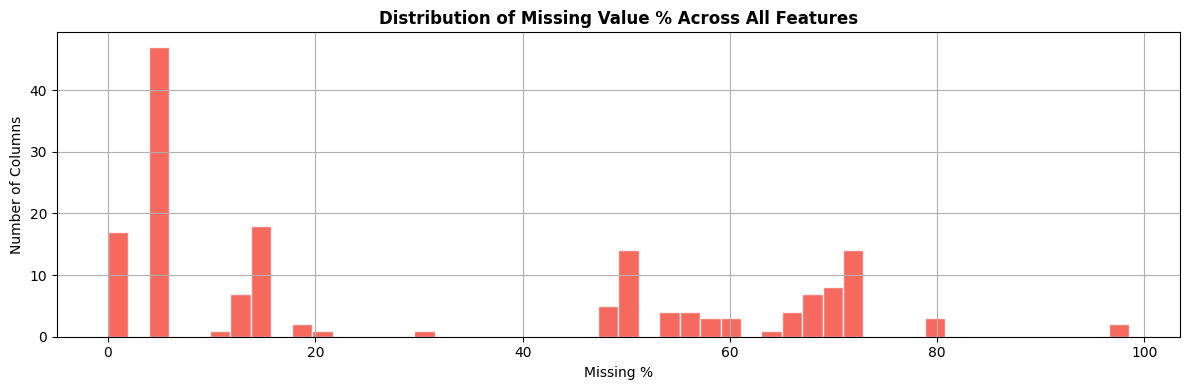

In [19]:
# Check missing value distribution
missing_pct = (train_master.isnull().sum() / len(train_master) * 100).sort_values(ascending=False)
print(f'Columns with >50% missing: {(missing_pct > 50).sum()}')
print(f'Columns with >80% missing: {(missing_pct > 80).sum()}')

fig, ax = plt.subplots(figsize=(12, 4))
missing_pct[missing_pct > 0].hist(bins=50, ax=ax, color='#F44336', edgecolor='white', alpha=0.8)
ax.set_xlabel('Missing %')
ax.set_ylabel('Number of Columns')
ax.set_title('Distribution of Missing Value % Across All Features', fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Drop columns with >80% missing
HIGH_MISSING_THRESHOLD = 80
cols_to_drop = missing_pct[missing_pct > HIGH_MISSING_THRESHOLD].index.tolist()
print(f'Dropping {len(cols_to_drop)} columns with >{HIGH_MISSING_THRESHOLD}% missing:')
print(cols_to_drop)

train_master.drop(columns=cols_to_drop, inplace=True)
test_master.drop(columns=[c for c in cols_to_drop if c in test_master.columns], inplace=True)

Dropping 5 columns with >80% missing:
['prev_rate_interest_max', 'prev_rate_interest_mean', 'cc_payment_ratio_mean', 'cc_atm_drawings_mean', 'cc_drawings_total_mean']


In [21]:
# Impute remaining numeric columns with median
# Impute categorical columns with mode

num_cols = train_master.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train_master.select_dtypes(include=['object']).columns.tolist()

# Exclude TARGET from imputation
num_cols_to_impute = [c for c in num_cols if c != 'TARGET']

# Compute medians from train only, apply to both
num_medians = train_master[num_cols_to_impute].median()
train_master[num_cols_to_impute] = train_master[num_cols_to_impute].fillna(num_medians)
test_master[num_cols_to_impute]  = test_master[[c for c in num_cols_to_impute
                                                if c in test_master.columns]].fillna(
    num_medians[[c for c in num_cols_to_impute if c in test_master.columns]]
)

# Categorical: fill with 'Unknown'
for col in cat_cols:
    train_master[col].fillna('Unknown', inplace=True)
    if col in test_master.columns:
        test_master[col].fillna('Unknown', inplace=True)

remaining_missing = train_master.isnull().sum().sum()
print(f'Remaining missing values in train: {remaining_missing}')
print(f'Remaining missing values in test : {test_master.isnull().sum().sum()}')

Remaining missing values in train: 0
Remaining missing values in test : 0


---
## 10. Encode Categorical Features

In [22]:
cat_cols = train_master.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode ({len(cat_cols)}): {cat_cols}')

Categorical columns to encode (16): ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [23]:
# Label encode columns with <=2 unique values
# One-hot encode columns with 3–15 unique values
# High cardinality (>15) → label encode to avoid explosion

le = LabelEncoder()
ohe_cols, le_cols, high_card_cols = [], [], []

for col in cat_cols:
    n_unique = train_master[col].nunique()
    if n_unique <= 2:
        le_cols.append(col)
    elif n_unique <= 15:
        ohe_cols.append(col)
    else:
        high_card_cols.append(col)

print(f'Binary label encode   : {len(le_cols)} cols')
print(f'One-hot encode        : {len(ohe_cols)} cols')
print(f'High-card label encode: {len(high_card_cols)} cols')

# Binary encode
for col in le_cols:
    combined = pd.concat([train_master[col], test_master[col]]).astype(str)
    le.fit(combined)
    train_master[col] = le.transform(train_master[col].astype(str))
    test_master[col]  = le.transform(test_master[col].astype(str))

# High cardinality label encode
for col in high_card_cols:
    combined = pd.concat([train_master[col], test_master[col]]).astype(str)
    le.fit(combined)
    train_master[col] = le.transform(train_master[col].astype(str))
    test_master[col]  = le.transform(test_master[col].astype(str))

# One-hot encode
train_master = pd.get_dummies(train_master, columns=ohe_cols, dummy_na=False)
test_master  = pd.get_dummies(test_master,  columns=ohe_cols, dummy_na=False)

# Align columns (test may be missing some OHE columns from train)
train_cols = [c for c in train_master.columns if c != 'TARGET']
missing_in_test = set(train_cols) - set(test_master.columns)
for col in missing_in_test:
    test_master[col] = 0

test_master = test_master[[c for c in train_cols if c in test_master.columns]]

print(f'\nTrain final shape: {train_master.shape}')
print(f'Test  final shape: {test_master.shape}')

Binary label encode   : 3 cols
One-hot encode        : 11 cols
High-card label encode: 2 cols

Train final shape: (307511, 274)
Test  final shape: (48744, 273)


---
## 11. Feature Importance Preview (Correlation with TARGET)

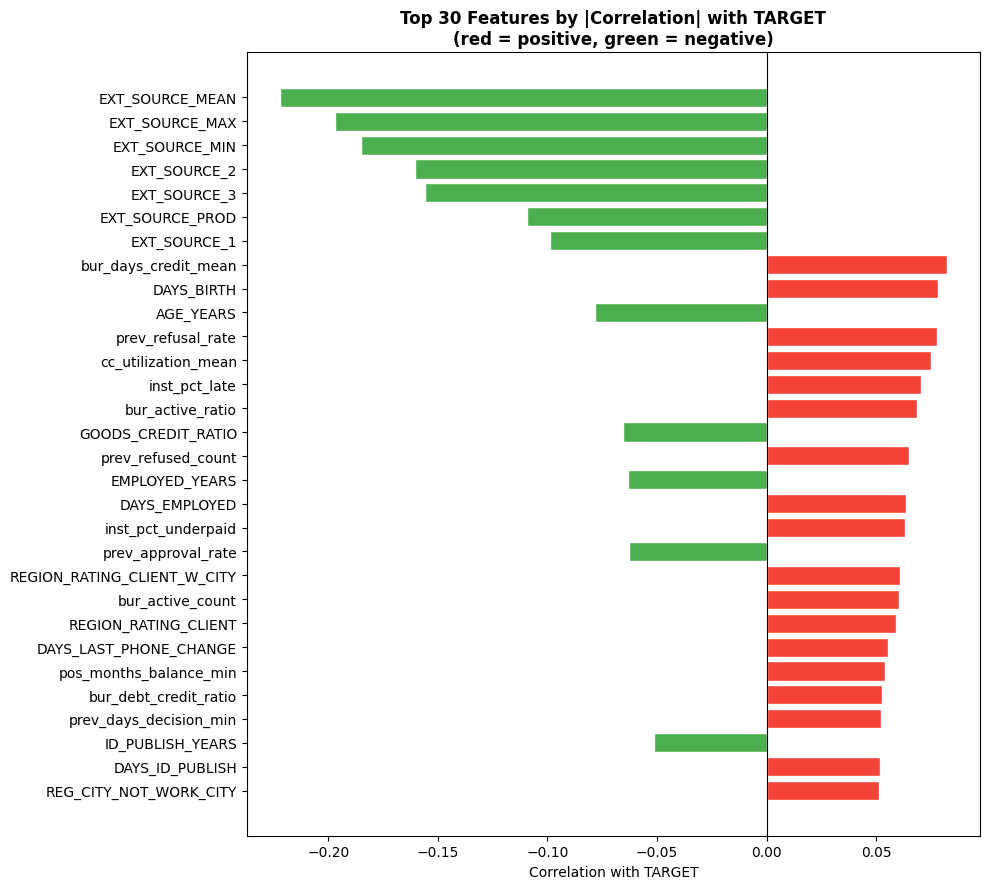

In [24]:
# Top 30 features by absolute correlation with TARGET
num_feats = train_master.select_dtypes(include=[np.number]).columns.tolist()
corr_target = train_master[num_feats].corr()['TARGET'].drop('TARGET')
top30 = corr_target.abs().nlargest(30)
top30_signed = corr_target[top30.index]

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#F44336' if v > 0 else '#4CAF50' for v in top30_signed.values]
ax.barh(top30_signed.index[::-1], top30_signed.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with TARGET')
ax.set_title('Top 30 Features by |Correlation| with TARGET\n(red = positive, green = negative)',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Save Processed Feature Sets

In [25]:
SAVE_PATH = DATA_PATH  # save alongside raw data

train_out = os.path.join(SAVE_PATH, 'train_features.csv')
test_out  = os.path.join(SAVE_PATH, 'test_features.csv')

train_master.to_csv(train_out, index=False)
test_master.to_csv(test_out,   index=False)

print(f'✅ Saved train_features.csv → {train_out}')
print(f'✅ Saved test_features.csv  → {test_out}')
print(f'\nFinal train shape : {train_master.shape}')
print(f'Final test  shape : {test_master.shape}')
print(f'\nTarget distribution:')
print(train_master['TARGET'].value_counts(normalize=True).round(4))

✅ Saved train_features.csv → /Users/salmaahmed/.cache/kagglehub/competitions/home-credit-default-risk/train_features.csv
✅ Saved test_features.csv  → /Users/salmaahmed/.cache/kagglehub/competitions/home-credit-default-risk/test_features.csv

Final train shape : (307511, 274)
Final test  shape : (48744, 273)

Target distribution:
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64


---
## Summary

| Step | What we did |
|------|-------------|
| App features | Age, employment, income ratios, EXT_SOURCE combinations, document flags, enquiry totals |
| Bureau | Credit counts, overdue ratios, debt/credit ratio, DPD months from bureau balance |
| Prev App | Approval/refusal rates, credit amounts, app-to-credit ratio, interest rates |
| POS CASH | DPD mean/max/rate, active ratio, months of history |
| Credit Card | Utilization mean/max, DPD rate, payment ratio, drawing behaviour |
| Installments | % late payments, avg days late, payment ratio, underpayment rate |
| Missing | Dropped >80% missing; median imputation for numerics, 'Unknown' for categoricals |
| Encoding | Binary → label encode; low-card → one-hot; high-card → label encode |

**Output files:**
- `train_features.csv` — full engineered feature matrix with TARGET
- `test_features.csv`  — same features, no TARGET (for submission)

**Next step:** Load these CSVs into a modeling notebook and train LightGBM / XGBoost.